# Phase 8: Model Explainability - Dubai Apartment Price Prediction

## Objectives
- Load the best model (`models/model.pkl`) and preprocessor (`models/preprocessor.pkl`)
- Calculate SHAP (SHapley Additive exPlanations) values to explain feature contributions
- Generate a global summary plot showing which features have the strongest positive or negative influence on property price predictions
- Generate a local waterfall plot explaining a single property prediction

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import os

print('Explainability imports successful!')

C:\Users\adith\OneDrive\Desktop\Real-estate\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explainability imports successful!


### Load Model and Data

In [2]:
model = joblib.load('models/model.pkl')
preprocessor = joblib.load('models/preprocessor.pkl')
df = pd.read_csv('data/ready_cleaned_v2.csv')

num_features = ['beds', 'baths', 'area', 'luxury_score', 'has_view', 'has_maids_room', 'is_freehold', 'dist_to_burj', 'dist_to_airport', 'dist_to_beach']
cat_features = ['furnished']
X = df[num_features + ['district'] + cat_features]
y = df['log_price']

print('Model loaded successfully!')

Model loaded successfully!


### Transform Features and Extract Feature Names

In [3]:
X_proc = preprocessor.transform(X)
if hasattr(X_proc, 'toarray'):
    X_proc = X_proc.toarray()

# Get feature names
all_features = [f.split('__')[-1] for f in preprocessor.get_feature_names_out()]

print(f'Processed feature count: {len(all_features)}')
print('Feature names:', all_features)

Processed feature count: 14
Feature names: ['beds', 'baths', 'area', 'luxury_score', 'has_view', 'has_maids_room', 'is_freehold', 'dist_to_burj', 'dist_to_airport', 'dist_to_beach', 'district', 'furnished_Furnished', 'furnished_Unfurnished', 'furnished_Unknown']


### Initialize SHAP TreeExplainer
We explain the first 100 samples to keep computation fast.

In [4]:
# Extract the XGBoost estimator from the VotingRegressor ensemble for Tree SHAP
xgb_estimator = model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_estimator)
shap_values = explainer(X_proc[:100])
print('SHAP values calculated successfully!')

SHAP values calculated successfully!


### Global Explanations: Summary Plot

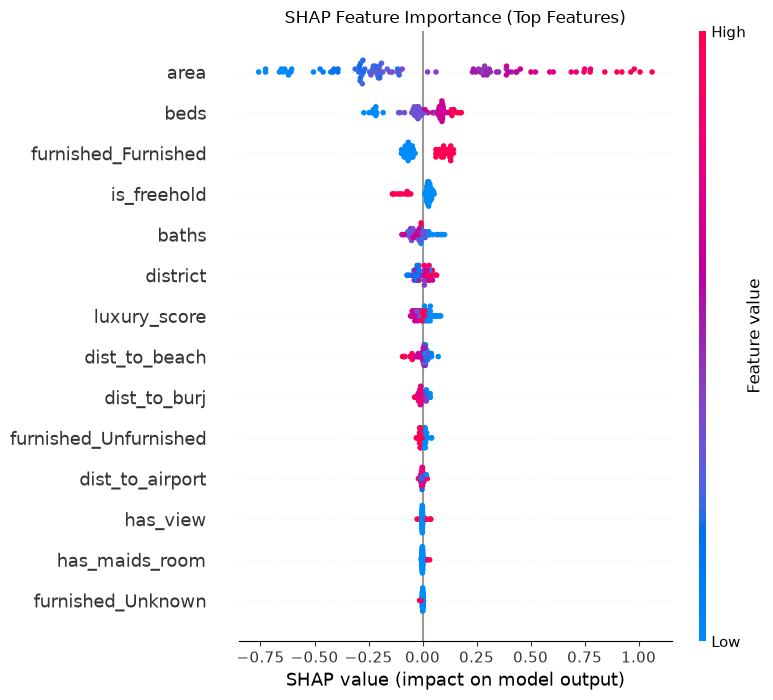

In [5]:
os.makedirs('reports', exist_ok=True)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_proc[:100], feature_names=all_features, show=False)
plt.title('SHAP Feature Importance (Top Features)')
plt.tight_layout()
plt.savefig('reports/shap_summary.png')
plt.show()

### Local Explanations: Waterfall Plot
We explain the prediction for the first property in our dataset.

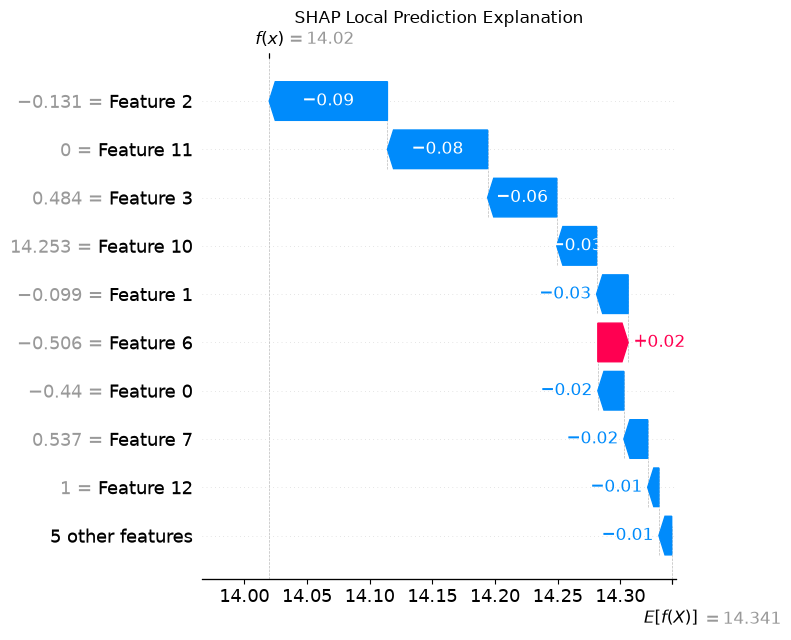

In [6]:
plt.figure(figsize=(10, 4))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Local Prediction Explanation')
plt.tight_layout()
plt.savefig('reports/shap_local.png')
plt.show()

### Explainability Conclusions
1. **Area** is the primary driver of apartment prices. A larger area has a massive positive impact on the price.
2. **Luxury Score** and **Beds** have strong positive impacts on valuation.
3. Specific locations like **Downtown Dubai** and **Dubai Marina** shift predictions significantly upward, while other outlying districts shift them downward.